## Контрольная самостоятельная работа

**Время выполнения**: 90 минут

**Инструкции**: Ответьте на теоретические вопросы и выполните практические задания, используя Python или вручную.

### Часть 1: Теория

1. Объясните, что такое MSE и MAE. В каких случаях один показатель предпочтительнее другого?
2. Опишите метод RANSAC и приведите пример его применения для борьбы с выбросами.
3. Как работает правило 3 сигм? Какие ограничения у этого подхода?

**1.**
MSE (Mean Squared Error, среднеквадратичная ошибка) и MAE (Mean Absolute Error, средняя абсолютная ошибка) — это два широко используемых показателя для оценки качества модели в задачах регрессии. Оба они измеряют разницу между предсказанными значениями и реальными наблюдениями, но делают это по-разному, что влияет на их интерпретацию и предпочтительность в разных ситуациях.

**MSE:**

MSE вычисляется как среднее значение квадратов разностей между реальными значениями и предсказаниями модели:

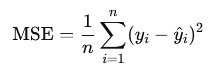

где:

yi​ — реальные значения,
Ŷ​ — предсказанные значения,
n — количество наблюдений.

Особенности:

MSE штрафует большие ошибки сильнее, чем маленькие, поскольку разность между реальным и предсказанным значением возводится в квадрат. Это делает MSE чувствительным к выбросам.
MSE является дифференцируемой функцией, что делает его удобным для оптимизации в таких алгоритмах, как градиентный спуск.

Когда MSE предпочтительнее:

Когда важно минимизировать крупные ошибки. Например, в задачах, где большие ошибки могут привести к серьезным последствиям (например, прогнозирование цен на рынке, медицинские диагностики).
Когда модель должна быть чувствительна к выбросам, чтобы устранить их влияние.

**MAE:**

MAE вычисляется как среднее значение абсолютных разностей между реальными значениями и предсказаниями:

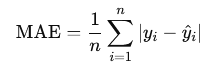

Особенности:

MAE менее чувствительна к выбросам, чем MSE, так как ошибки измеряются в абсолютных величинах, а не в квадрате. Это делает его более устойчивым к экстремальным значениям.
MAE проще в интерпретации, поскольку она выражает среднюю ошибку в тех же единицах, что и исходные данные (в отличие от MSE, где ошибка выражена в квадратах единиц).

Когда MAE предпочтительнее:

Когда важно, чтобы модель была устойчива к выбросам и не "наказана" сильно за редкие, но большие ошибки.
В задачах, где важно минимизировать медианную ошибку или когда ошибки должны быть равномерно оценены, а не вознаграждаться за мелкие ошибки и наказываться за крупные.

Когда выбирать:

Если модель должна быть более чувствительной к большим ошибкам, выбирают MSE.
Если необходимо избегать воздействия выбросов и важна стабильность ошибки, выбирают MAE.

**2.**
RANSAC (Random Sample Consensus) — это алгоритм для оценки параметров модели, который устойчив к выбросам. Он часто используется в задачах регрессии, где необходимо подобрать модель (например, прямую или плоскость), а также в задачах компьютерного зрения, например, для нахождения соответствий между изображениями. Основная идея метода заключается в том, чтобы найти такие параметры модели, которые максимально подходят к данным, игнорируя выбросы.

Принцип работы RANSAC:

* Выбор случайной подвыборки: Для нахождения модели выбирается случайная
подвыборка данных. Эта подвыборка должна быть достаточно маленькой, чтобы минимизировать влияние выбросов.

* Оценка модели: На основе выбранной подвыборки вычисляется модель. Например, если задача — это линейная регрессия, то для выбранной подвыборки вычисляется линия.

* Оценка всех точек: После того как модель найдена, для каждой точки данных вычисляется ее расстояние до модели. Точки, которые лежат достаточно близко к модели (в пределах заранее определенного порога), считаются корректными точками, а остальные — "выбросами".

* Повторение: Алгоритм повторяет этот процесс несколько раз, каждый раз выбирая случайную подвыборку и оценивая модель.

* Выбор лучшей модели: В конце алгоритм выбирает модель, которая имеет наибольшее количество инлайнеров — точек, которые хорошо согласуются с моделью. Модель с максимальным количеством инлайнеров считается наиболее подходящей.

**Пример**

Пример применения RANSAC для борьбы с выбросами

Предположим, у нас есть набор данных, состоящий из точек на плоскости, и мы хотим провести линейную регрессию для нахождения линии, которая наилучшим образом описывает зависимость между переменными. Однако данные содержат выбросы, которые сильно искажают результаты простой линейной регрессии.

Шаги:

* Инициализация: У нас есть набор данных, и мы знаем, что примерно 90% из них должны быть на прямой, а 10% — выбросы.

* Применение RANSAC:
Сначала случайным образом выбираем две точки из набора данных и строим прямую через эти точки.
Вычисляем расстояние от каждой точки данных до этой прямой.
Все точки, расстояние которых от прямой меньше определенного порога (например, 0.5), считаются инлайнерами.

* Повторение:
Процесс повторяется несколько тысяч раз, каждый раз с выбором разных пар точек и построением новой прямой.

* Выбор лучшей модели:
После выполнения всех итераций выбираем модель (прямую), которая имеет наибольшее количество инлайнеров.

* Получение результата:
Модель, найденная с помощью RANSAC, будет игнорировать выбросы и максимально точно описывать основную зависимость.

**3.**
Правило 3 сигм (или правило трёх стандартных отклонений) — это статистический принцип, который используется для оценки и выявления выбросов в данных. Согласно этому правилу, в нормально распределенных данных (или данных, которые можно аппроксимировать нормальным распределением) более 99% наблюдений должны находиться в пределах от трех стандартных отклонений от среднего значения.

Как работает правило 3 сигм:

Определение среднего и стандартного отклонения:
        Рассчитывается среднее значение (μ) выборки.
        Рассчитывается стандартное отклонение (σ), которое измеряет, насколько сильно отклоняются данные от среднего значения.

Применение правила 3 сигм:
        Согласно правилу, для нормально распределенных данных почти все значения (около 99.7%) должны находиться в интервале от μ−3σ до μ+3σ.
        Все значения, которые выходят за эти пределы, считаются выбросами, то есть такими точками, которые существенно отличаются от основной массы данных.

Практическое применение:
        Вычисляется интервал: μ−3σ до μ+3σ.
        Все данные, которые находятся за пределами этого интервала, идентифицируются как выбросы.

**Ограничения** подхода 3 сигм:

* Предположение о нормальном распределении:
Это правило предполагает, что данные следуют нормальному распределению (или хотя бы близки к нему). Однако на практике многие данные не подчиняются нормальному распределению, а могут быть асимметричными или иметь тяжелые хвосты. В таких случаях использование правила 3 сигм может быть неэффективным, так как оно будет слишком жестко классифицировать значения как выбросы.

* Чувствительность к выбросам:
Если в данных уже есть выбросы, то стандартное отклонение будет увеличено, что приведет к увеличению диапазона, в котором данные считаются нормальными. Это может привести к тому, что реальные выбросы останутся незамеченными.

* Не учитывает контекст данных:
Правило 3 сигм не принимает во внимание контекст задачи или природу данных. Например, в некоторых приложениях выбросы могут быть важными, например, в финансовых данных, где экстремальные значения могут быть сигналом о значимых событиях, таких как резкие изменения на рынке.

* Не подходит для многомерных данных:
Если данные имеют несколько переменных (многомерные данные), правило 3 сигм не применимо в своей базовой форме, поскольку стандартное отклонение и среднее для многомерных данных вычисляются сложнее. В таких случаях нужно использовать другие методы, такие как метод главных компонент или многомерные подходы для выявления выбросов.

* Игнорирует возможные закономерности в данных:
В некоторых случаях выбросы могут быть следствием закономерных событий, которые не должны быть удалены. Например, в биологических или финансовых данных экстремальные значения могут быть нормальной частью процесса, но правило 3 сигм не может учесть такие особенности.

### Часть 2: Практика


#### Задача 1

С использованием данных о зарплатах и вкладах, содержащихся в массиве `developers`:
1. Постройте линейную регрессию.
2. Рассчитайте метрики качества модели: MSE, MAE, R².

   Salary  Deposit
0  370297   670734
1  341714   956799
2  276448   748792
3  399566   994462
4  259584   711670
MSE (Среднеквадратичная ошибка): 2956819726.3892117
MAE (Средняя абсолютная ошибка): 47424.40224610428
R² (Коэффициент детерминации): 0.008450597461282738


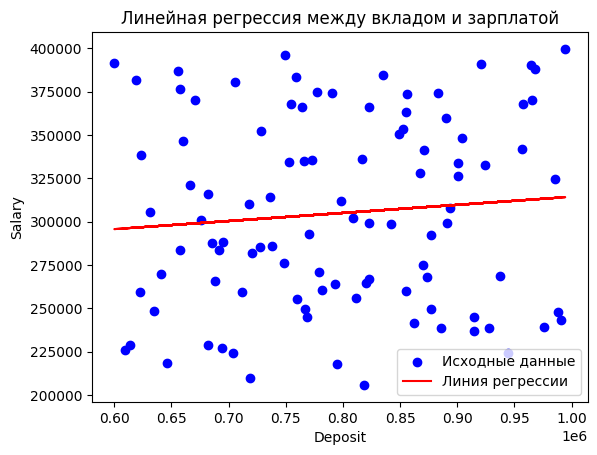

In [ ]:
# Задача 1
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv('developers.csv')

# просмотр первых нескольких строк данных
print(df.head())

# разделяю данные на переменные X (вклады) и y (зарплаты)
X = df[['Deposit']]
y = df['Salary']

# создание и обучение модели линейной регрессии
model = LinearRegression()
model.fit(X, y)

# предсказания на основе обученной модели
y_pred = model.predict(X)

# расчет метрик
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

# вывод метрик
print(f'MSE (Среднеквадратичная ошибка): {mse}')
print(f'MAE (Средняя абсолютная ошибка): {mae}')
print(f'R² (Коэффициент детерминации): {r2}')

# визуализация данных и линии регрессии
plt.scatter(X, y, color='blue', label='Исходные данные')
plt.plot(X, y_pred, color='red', label='Линия регрессии')
plt.xlabel('Deposit')
plt.ylabel('Salary')
plt.title('Линейная регрессия между вкладом и зарплатой')
plt.legend()
plt.show()


#### Задача 2

Используя правило 3 сигм:
1. Удалите выбросы из выборки `iqs` (IQ людей).
2. Постройте гистограмму данных до и после удаления выбросов.

       IQ
0  107.45
1   97.93
2  109.72
3  122.85
4   96.49


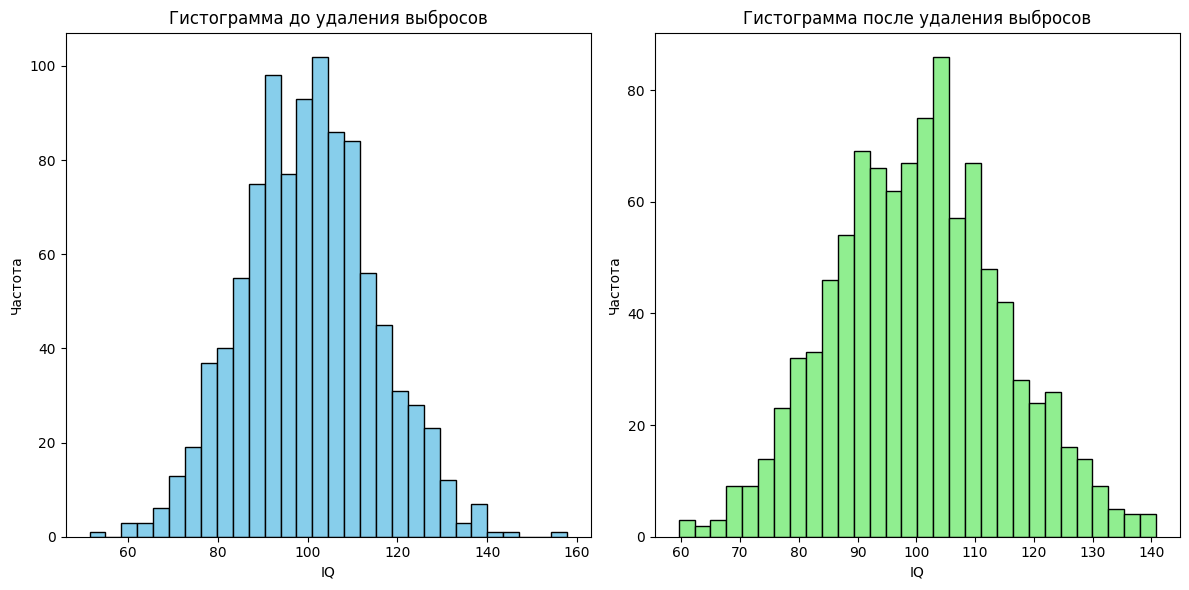

In [ ]:
# Задача 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('iqs.csv')

# просмотр первых нескольких строк данных
print(df.head())

# рассчитываю среднее и стандартное отклонение для IQ
mean_iq = df['IQ'].mean()
std_iq = df['IQ'].std()

# применяю правило 3 сигм для определения выбросов
lower_bound = mean_iq - 3 * std_iq
upper_bound = mean_iq + 3 * std_iq

# удаляю выбросы, оставляю только те значения, которые находятся в пределах от -3σ до +3σ
cleaned_df = df[(df['IQ'] >= lower_bound) & (df['IQ'] <= upper_bound)]

# построение гистограмм
plt.figure(figsize=(12, 6))

# гистограмма до удаления выбросов
plt.subplot(1, 2, 1)
plt.hist(df['IQ'], bins=30, color='skyblue', edgecolor='black')
plt.title('Гистограмма до удаления выбросов')
plt.xlabel('IQ')
plt.ylabel('Частота')

# гистограмма после удаления выбросов
plt.subplot(1, 2, 2)
plt.hist(cleaned_df['IQ'], bins=30, color='lightgreen', edgecolor='black')
plt.title('Гистограмма после удаления выбросов')
plt.xlabel('IQ')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()


#### Задача 3

На наборе данных с выбросами:
1. Постройте линейную регрессию с использованием всех точек (включая выбросы).
2. Примените метод RANSAC для построения регрессии.  
Сравните результаты.

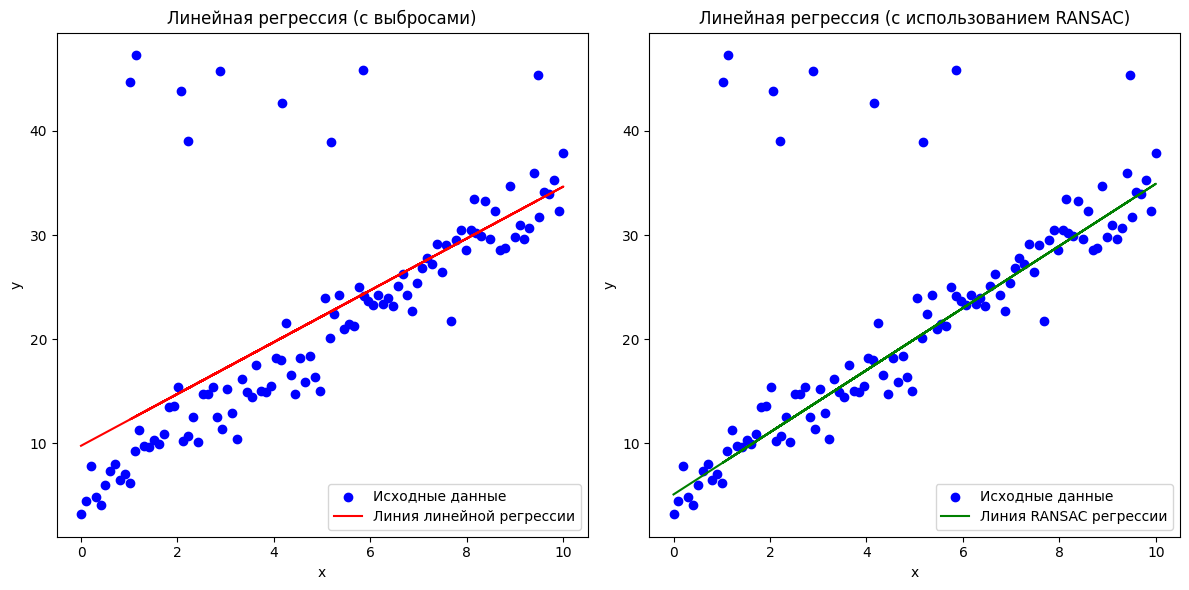

In [ ]:
# Задача 3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, RANSACRegressor

# генерация данных
x = np.linspace(0, 10, 100).reshape(-1, 1)  # 100 точек от 0 до 10
y = 3 * x.squeeze() + 5 + np.random.randn(100) * 2  # Линейная зависимость с шумом

# генерация выбросов
outliers_x = np.random.uniform(0, 10, size=10).reshape(-1, 1)  # 10 случайных точек по x
outliers_y = np.random.uniform(30, 50, size=10)  # 10 случайных точек по y, которые являются выбросами

# добавляю выбросы к данным
x = np.vstack([x, outliers_x])
y = np.hstack([y, outliers_y])

# построение линейной регрессии с использованием всех данных (включая выбросы)
linear_model = LinearRegression()
linear_model.fit(x, y)
y_pred_linear = linear_model.predict(x)

# применение метода RANSAC для построения регрессии
ransac_model = RANSACRegressor()
ransac_model.fit(x, y)
y_pred_ransac = ransac_model.predict(x)

# визуализация результатов
plt.figure(figsize=(12, 6))

# 1. линейная регрессия (с выбросами)
plt.subplot(1, 2, 1)
plt.scatter(x, y, color='blue', label='Исходные данные')
plt.plot(x, y_pred_linear, color='red', label='Линия линейной регрессии')
plt.title('Линейная регрессия (с выбросами)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

# 2. результат RANSAC
plt.subplot(1, 2, 2)
plt.scatter(x, y, color='blue', label='Исходные данные')
plt.plot(x, y_pred_ransac, color='green', label='Линия RANSAC регрессии')
plt.title('Линейная регрессия (с использованием RANSAC)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.tight_layout()
plt.show()
